In [1]:
import sys
sys.path.append('C:/Users/sliso/LastTradingProject_7052026/indicators')

In [45]:
import numpy as np
import json
import random
from collections import defaultdict, Counter
from itertools import product
from tqdm import tqdm
import numba
import numpy as np
from collections import defaultdict, Counter
from itertools import product
from RSI import RSI
from MACD import MACD
from STOCH import STOCH
from ADX import ADX
from AROON import AROON
from BBWidth import BBWidth
from EhlersReflexDiv import EhlersReflexDiv
from EIT import EIT
from ESSV import ESSV
from GarmanKlass import GarmanKlass
from RsiDiv import RsiDiv
from StochDiv import StochDiv
import pandas as pd

In [46]:
data=pd.read_csv("../df_test.csv", parse_dates=['Date'], index_col='Date')

In [47]:
def precompute_raw_signals(indicators, data):
    raw = {}
    meta = {}
    for ind in indicators:
        ind_name = ind.__class__.__name__
        for method_name in dir(ind):
            method = getattr(ind, method_name)
            if callable(method) and hasattr(method, '_signal_meta'):
                arr = method()
                if isinstance(arr, pd.Series):
                    arr = arr.values
                raw[f"{ind_name}.{method_name}"] = arr.astype(np.int8)
                meta[f"{ind_name}.{method_name}"] = {
                    'direction': method._signal_meta['direction'],
                    'type': method._signal_meta['type'],
                }
    return raw, meta

def binary_signal_from_raw(method_str, role, raw, meta):
    arr = raw[method_str]
    direction = meta[method_str]['direction']
    if role in ('entry_long', 'exit_short'):
        if direction == 'long':
            return arr == 1
        elif direction == 'both':
            return arr == 1
        else:
            return np.zeros(len(arr), dtype=bool)
    elif role in ('exit_long', 'entry_short'):
        if direction == 'short':
            return arr == -1
        elif direction == 'both':
            return arr == 1
        else:
            return np.zeros(len(arr), dtype=bool)
    else:
        return np.zeros(len(arr), dtype=bool)

def evaluate_strategy_metrics(strategy, raw, meta, returns, chunk_slice):
    """Return (sharpe, total_return, max_drawdown)."""
    # Build boolean arrays (same as before)
    el_bool = np.ones(len(returns), dtype=bool)
    for sig in strategy['entry_long']:
        if sig not in raw:
            return -np.inf, 0, 1.0
        el_bool &= binary_signal_from_raw(sig, 'entry_long', raw, meta)
    xl_bool = np.ones(len(returns), dtype=bool)
    for sig in strategy['exit_long']:
        if sig not in raw:
            return -np.inf, 0, 1.0
        xl_bool &= binary_signal_from_raw(sig, 'exit_long', raw, meta)
    es_bool = np.ones(len(returns), dtype=bool)
    for sig in strategy['entry_short']:
        if sig not in raw:
            return -np.inf, 0, 1.0
        es_bool &= binary_signal_from_raw(sig, 'entry_short', raw, meta)
    xs_bool = np.ones(len(returns), dtype=bool)
    for sig in strategy['exit_short']:
        if sig not in raw:
            return -np.inf, 0, 1.0
        xs_bool &= binary_signal_from_raw(sig, 'exit_short', raw, meta)

    el = el_bool[chunk_slice]
    xl = xl_bool[chunk_slice]
    es = es_bool[chunk_slice]
    xs = xs_bool[chunk_slice]
    rets = returns[chunk_slice]

    positions = fast_positions(el, xl, es, xs)
    strat_returns = np.roll(positions, 1) * rets
    strat_returns[0] = 0
    strat_returns = strat_returns[~np.isnan(strat_returns)]
    if len(strat_returns) == 0:
        return -np.inf, 0, 1.0

    total_return = np.prod(1 + strat_returns) - 1
    if np.std(strat_returns) == 0:
        sharpe = -np.inf
    else:
        sharpe = np.sqrt(252) * np.mean(strat_returns) / np.std(strat_returns)

    # Compute max drawdown
    cum_returns = np.cumprod(1 + strat_returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = np.min(drawdown)  # negative number, e.g., -0.15

    return sharpe, total_return, max_drawdown

In [48]:
@numba.njit(cache=True)
def fast_positions(entry_long, exit_long, entry_short, exit_short):
    n = len(entry_long)
    pos = np.zeros(n, dtype=np.int8)
    current = 0
    for i in range(n):
        if current == 0:
            if entry_long[i]:
                current = 1
            elif entry_short[i]:
                current = -1
        elif current == 1:
            if exit_long[i]:
                current = 0
        elif current == -1:
            if exit_short[i]:
                current = 0
        pos[i] = current
    return pos

In [49]:
def test_single_strategy(strategy, indicators, data, 
                         pre_screen_bars=None,
                         return_positions=False):
    """
    Test a single strategy on the given data.

    Parameters:
    -----------
    strategy : dict
        Must have keys 'entry_long', 'exit_long', 'entry_short', 'exit_short',
        each a list of signal strings (e.g., ["RSI.cross_above_down_level_long"]).
    indicators : list
        List of indicator instances (e.g., [rsi, stoch, adx, ...]).
    data : pd.DataFrame
        OHLC data with 'Close' column.
    pre_screen_bars : int, optional
        If provided, test only the first `pre_screen_bars` bars. Otherwise test all data.
    return_positions : bool, default False
        If True, also return positions (pd.Series) and equity curve.

    Returns:
    --------
    dict with keys: 'sharpe', 'total_return', 'max_drawdown'
    (plus 'positions' and 'equity' if return_positions=True)
    """
    # 1. Pre‑compute raw signals
    raw, meta = precompute_raw_signals(indicators, data)
    returns = data['Close'].pct_change().fillna(0).values

    # 2. Determine chunk
    if pre_screen_bars is None:
        chunk_slice = slice(0, len(data))
    else:
        chunk_slice = slice(0, min(pre_screen_bars, len(data)))

    # 3. Evaluate metrics
    sharpe, total_ret, max_dd = evaluate_strategy_metrics(
        strategy, raw, meta, returns, chunk_slice
    )

    result = {
        'sharpe': sharpe,
        'total_return': total_ret,
        'max_drawdown': max_dd
    }

    # 4. Optionally compute positions and equity curve for further analysis
    if return_positions:
        # Build boolean arrays for the full data (same as in evaluate_strategy_metrics)
        el_bool = np.ones(len(returns), dtype=bool)
        for sig in strategy['entry_long']:
            if sig in raw:
                el_bool &= binary_signal_from_raw(sig, 'entry_long', raw, meta)
        xl_bool = np.ones(len(returns), dtype=bool)
        for sig in strategy['exit_long']:
            if sig in raw:
                xl_bool &= binary_signal_from_raw(sig, 'exit_long', raw, meta)
        es_bool = np.ones(len(returns), dtype=bool)
        for sig in strategy['entry_short']:
            if sig in raw:
                es_bool &= binary_signal_from_raw(sig, 'entry_short', raw, meta)
        xs_bool = np.ones(len(returns), dtype=bool)
        for sig in strategy['exit_short']:
            if sig in raw:
                xs_bool &= binary_signal_from_raw(sig, 'exit_short', raw, meta)

        el = el_bool[chunk_slice]
        xl = xl_bool[chunk_slice]
        es = es_bool[chunk_slice]
        xs = xs_bool[chunk_slice]

        positions = fast_positions(el, xl, es, xs)
        strat_returns = np.roll(positions, 1) * returns[chunk_slice]
        strat_returns[0] = 0
        equity = np.cumprod(1 + strat_returns)

        result['positions'] = pd.Series(positions, index=data.index[chunk_slice])
        result['equity'] = pd.Series(equity, index=data.index[chunk_slice])

    return result

In [50]:
rsi=RSI(data)
macd=MACD(data)
stoch=STOCH(data)
adx=ADX(data)
aroon=AROON(data)
bbwidth=BBWidth(data)
ehlersrefdiv=EhlersReflexDiv(data)
eit=EIT(data)
essv=ESSV(data)
garmanklass=GarmanKlass(data)
rsidiv=RsiDiv(data)
stochdiv=StochDiv(data)
indicators = [rsi, macd, stoch, adx, aroon, bbwidth, ehlersrefdiv, eit, essv, garmanklass, rsidiv, stochdiv ]

Sharpe: -0.040
Return: -5.31%
Max DD: -12.84%


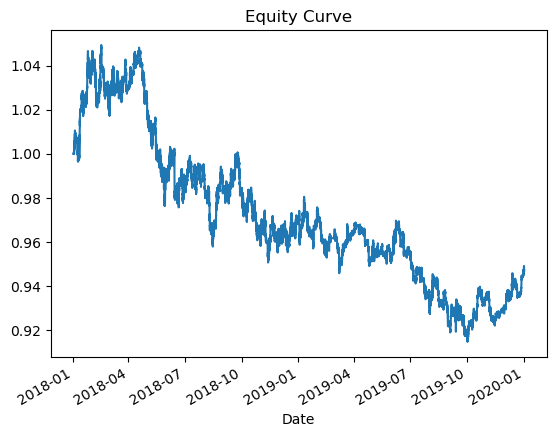

In [51]:
# The GA saves each strategy as a JSON line with keys 'strategy', 'sharpe', etc.
with open('ga_best_strategies.jsonl', 'r') as f:
    line = f.readline()
    record = json.loads(line)
    best_strategy = record['strategy']   # this is the dict with entry/exit lists

# Test it on the full dataset

result = test_single_strategy(best_strategy, indicators, data, return_positions=True)

print(f"Sharpe: {result['sharpe']:.3f}")
print(f"Return: {result['total_return']:.2%}")
print(f"Max DD: {result['max_drawdown']:.2%}")

# Plot equity curve
import matplotlib.pyplot as plt
result['equity'].plot()
plt.title("Equity Curve")
plt.show()

In [52]:
best_strategy

{'entry_long': ['AROON.weak_trend_regime', 'StochDiv.bullish_signal'],
 'exit_long': ['BBWidth.low_volatility_regime',
  'RSI.above_up_level_short',
  'STOCH.kd_cross_above_up_level_short'],
 'entry_short': ['GarmanKlass.low_volatility_regime',
  'AROON.strong_trend_regime',
  'EhlersReflexDiv.bearish_signal'],
 'exit_short': ['ESSV.volatility_low', 'StochDiv.bullish_signal']}

In [53]:
result['AROON_WEAK_TREND']=aroon.weak_trend_regime()



In [54]:
result['STOCH_DIV_BULL']=stochdiv.bullish_signal()

In [55]:
result['STOCH_DIV_BEAR']=stochdiv.bearish_signal()

In [56]:
result['BB_WIDTH_LOW_VOL']=bbwidth.low_volatility_regime()

In [57]:
result['RSI_ABOVE_UP_LEVEL']=rsi.above_up_level_short()

In [58]:
result['STOCH_KD_CROSS_ABOVE_UP']=stoch.kd_cross_above_up_level_short()

In [59]:
result['GK_LOW_VOL_REGIME']=garmanklass.low_volatility_regime()

In [60]:
result['AROON_STRONG_TREND']=aroon.strong_trend_regime()

In [61]:
result['EHLERS_REFLEX_BEARISH']=ehlersrefdiv.bearish_signal()

In [62]:
result['ESSV_VOL_LOW']=essv.volatility_low()

In [63]:
result['STOCH_DIV_BULL']=stochdiv.bullish_signal()

In [64]:
result_df=pd.DataFrame(result)

In [72]:
result_df[(result_df.positions == 1)&((result_df.positions.shift(1) == 0)|(result_df.positions.shift(1) == -1))]


,sharpe,total_return,max_drawdown,positions,equity,AROON_WEAK_TREND,STOCH_DIV_BULL,STOCH_DIV_BEAR,BB_WIDTH_LOW_VOL,RSI_ABOVE_UP_LEVEL,STOCH_KD_CROSS_ABOVE_UP,GK_LOW_VOL_REGIME,AROON_STRONG_TREND,EHLERS_REFLEX_BEARISH,ESSV_VOL_LOW
Date,,,,,,,,,,,,,,,
2018-01-03 23:30:00,-0.039849,-0.053124,-0.128353,1,1.004070,1,1,0,0,0,0,0,0,0,0
2018-04-03 21:45:00,-0.039849,-0.053124,-0.128353,1,1.036227,1,1,0,1,0,0,1,0,0,1
2018-04-20 00:45:00,-0.039849,-0.053124,-0.128353,1,1.046375,1,1,0,1,0,0,1,0,0,1
2019-02-27 22:15:00,-0.039849,-0.053124,-0.128353,1,0.961712,1,1,0,1,0,0,1,0,0,1
2019-03-28 19:30:00,-0.039849,-0.053124,-0.128353,1,0.963930,1,1,0,0,0,0,0,0,0,0
2019-04-15 12:00:00,-0.039849,-0.053124,-0.128353,1,0.965325,1,1,0,1,0,0,1,0,0,1
2019-05-15 19:30:00,-0.039849,-0.053124,-0.128353,1,0.957509,1,1,0,1,0,0,1,0,0,0
2019-06-25 22:30:00,-0.039849,-0.053124,-0.128353,1,0.955337,1,1,0,1,0,0,0,0,0,1
2019-10-31 18:45:00,-0.039849,-0.053124,-0.128353,1,0.935024,1,1,0,0,0,0,0,0,0,0


In [93]:
result_df.loc['2018-01-03 22:00':'2018-04-02 13:30'].iloc[-10:]

,sharpe,total_return,max_drawdown,positions,equity,AROON_WEAK_TREND,STOCH_DIV_BULL,STOCH_DIV_BEAR,BB_WIDTH_LOW_VOL,RSI_ABOVE_UP_LEVEL,STOCH_KD_CROSS_ABOVE_UP,GK_LOW_VOL_REGIME,AROON_STRONG_TREND,EHLERS_REFLEX_BEARISH,ESSV_VOL_LOW
Date,,,,,,,,,,,,,,,
2018-04-02 11:15:00,-0.039849,-0.053124,-0.128353,1,1.030848,0,0,0,1,0,0,1,1,0,1
2018-04-02 11:30:00,-0.039849,-0.053124,-0.128353,1,1.031459,0,0,0,1,-1,0,1,1,0,1
2018-04-02 11:45:00,-0.039849,-0.053124,-0.128353,1,1.031801,0,0,0,1,-1,0,1,1,0,1
2018-04-02 12:00:00,-0.039849,-0.053124,-0.128353,1,1.031751,0,0,0,1,-1,0,1,1,0,1
2018-04-02 12:15:00,-0.039849,-0.053124,-0.128353,0,1.031668,0,0,0,1,-1,-1,1,1,0,1
2018-04-02 12:30:00,-0.039849,-0.053124,-0.128353,-1,1.031668,0,0,-1,1,0,0,1,1,-1,1
2018-04-02 12:45:00,-0.039849,-0.053124,-0.128353,-1,1.031760,0,0,0,1,0,0,1,1,0,1
2018-04-02 13:00:00,-0.039849,-0.053124,-0.128353,-1,1.031760,0,0,0,1,0,0,1,1,0,1
2018-04-02 13:15:00,-0.039849,-0.053124,-0.128353,-1,1.032195,0,0,0,1,0,0,1,1,0,1


In [86]:
result_df[(result_df.positions == -1)&((result_df.positions.shift(1) == 0)|(result_df.positions.shift(1) == 1))]

,sharpe,total_return,max_drawdown,positions,equity,AROON_WEAK_TREND,STOCH_DIV_BULL,STOCH_DIV_BEAR,BB_WIDTH_LOW_VOL,RSI_ABOVE_UP_LEVEL,STOCH_KD_CROSS_ABOVE_UP,GK_LOW_VOL_REGIME,AROON_STRONG_TREND,EHLERS_REFLEX_BEARISH,ESSV_VOL_LOW
Date,,,,,,,,,,,,,,,
2018-01-02 23:45:00,-0.039849,-0.053124,-0.128353,-1,1.000000,0,0,-1,0,0,0,1,1,-1,1
2018-04-02 12:30:00,-0.039849,-0.053124,-0.128353,-1,1.031668,0,0,-1,1,0,0,1,1,-1,1
2018-04-03 03:15:00,-0.039849,-0.053124,-0.128353,-1,1.032412,0,0,0,1,0,0,1,1,-1,1
2018-04-17 20:45:00,-0.039849,-0.053124,-0.128353,-1,1.046775,0,0,0,0,0,0,1,1,-1,1
2019-03-24 21:00:00,-0.039849,-0.053124,-0.128353,-1,0.963209,0,0,0,0,0,0,1,1,-1,0
2019-03-25 04:00:00,-0.039849,-0.053124,-0.128353,-1,0.963192,0,0,0,1,0,0,1,1,-1,1
2019-04-01 05:30:00,-0.039849,-0.053124,-0.128353,-1,0.965098,0,0,0,1,-1,0,1,1,-1,1
2019-04-03 02:00:00,-0.039849,-0.053124,-0.128353,-1,0.968176,0,0,0,0,-1,0,1,1,-1,1
2019-04-04 07:45:00,-0.039849,-0.053124,-0.128353,-1,0.966712,0,0,-1,1,0,0,1,1,-1,1


In [87]:
result_df[(result_df.positions == 0)&((result_df.positions.shift(1) == -1)|(result_df.positions.shift(1) == 1))]

,sharpe,total_return,max_drawdown,positions,equity,AROON_WEAK_TREND,STOCH_DIV_BULL,STOCH_DIV_BEAR,BB_WIDTH_LOW_VOL,RSI_ABOVE_UP_LEVEL,STOCH_KD_CROSS_ABOVE_UP,GK_LOW_VOL_REGIME,AROON_STRONG_TREND,EHLERS_REFLEX_BEARISH,ESSV_VOL_LOW
Date,,,,,,,,,,,,,,,
2018-01-03 15:30:00,-0.039849,-0.053124,-0.128353,0,1.004070,0,1,0,0,0,0,0,1,0,1
2018-04-02 12:15:00,-0.039849,-0.053124,-0.128353,0,1.031668,0,0,0,1,-1,-1,1,1,0,1
2018-04-02 14:15:00,-0.039849,-0.053124,-0.128353,0,1.032412,0,1,0,0,0,0,1,1,0,1
2018-04-03 19:45:00,-0.039849,-0.053124,-0.128353,0,1.036227,1,1,0,1,0,0,0,0,0,1
2018-04-17 06:30:00,-0.039849,-0.053124,-0.128353,0,1.046775,0,0,0,1,-1,-1,1,1,0,1
2018-04-18 19:30:00,-0.039849,-0.053124,-0.128353,0,1.046375,0,1,0,1,0,0,0,0,0,1
2019-02-22 07:15:00,-0.039849,-0.053124,-0.128353,0,0.961712,0,0,0,1,-1,-1,1,1,0,1
2019-03-22 08:00:00,-0.039849,-0.053124,-0.128353,0,0.963209,0,0,-1,1,-1,-1,1,1,0,1
2019-03-25 00:15:00,-0.039849,-0.053124,-0.128353,0,0.963192,0,1,0,1,0,0,1,0,0,1
